In [29]:
import pandas as pd

In [30]:
movie_df = pd.read_csv(
    r"C:\Users\karth\OneDrive\Desktop\NLP poster\data\movie.csv"
)

irony_df = pd.read_csv(
    r"C:\Users\karth\OneDrive\Desktop\NLP Poster\data\irony.csv"
)

In [31]:
print("Movie shape:", movie_df.shape)
print(movie_df.head())

print("\nIrony shape:", irony_df.shape)
print(irony_df.head())

Movie shape: (561, 2)
  sentiment                                             review
0  positive  &quot;The Preacher's Kid&quot; last night. Tan...
1  positive  @username Sounds like a great day! Enjoy the B...
2  positive  'Edge of darkness' is a brilliant thriller, we...
3  positive     The Book of Eli? AWESOME. Two major thumbs up!
4  positive  Shutter Island was insane!! No pun intended. P...

Irony shape: (65, 2)
  sentiment                                             review
0  positive  In Service Today, We Were Talking About How Lu...
1  positive  @Khilafah101 ...typed out on Twitter invented ...
2  negative  As #KingObama grants #IllegalAmnesty #Mexico b...
3  negative  It would seem that all who is interested in Po...
4  negative     So the Heat are missing shots because it's hot


In [32]:
label_map = {
    "negative": 0,
    "positive": 1
}

movie_df["label"] = movie_df["sentiment"].map(label_map)
irony_df["label"] = irony_df["sentiment"].map(label_map)

print("Movie labels:")
print(movie_df["label"].value_counts())

print("\nIrony labels:")
print(irony_df["label"].value_counts())

Movie labels:
label
1    460
0    101
Name: count, dtype: int64

Irony labels:
label
0    43
1    22
Name: count, dtype: int64


In [33]:
print(movie_df.head())
print()
print(irony_df.head())

  sentiment                                             review  label
0  positive  &quot;The Preacher's Kid&quot; last night. Tan...      1
1  positive  @username Sounds like a great day! Enjoy the B...      1
2  positive  'Edge of darkness' is a brilliant thriller, we...      1
3  positive     The Book of Eli? AWESOME. Two major thumbs up!      1
4  positive  Shutter Island was insane!! No pun intended. P...      1

  sentiment                                             review  label
0  positive  In Service Today, We Were Talking About How Lu...      1
1  positive  @Khilafah101 ...typed out on Twitter invented ...      1
2  negative  As #KingObama grants #IllegalAmnesty #Mexico b...      0
3  negative  It would seem that all who is interested in Po...      0
4  negative     So the Heat are missing shots because it's hot      0


In [34]:
from sklearn.model_selection import train_test_split

# Movie dataset
movie_train, movie_test = train_test_split(
    movie_df,
    test_size=0.2,
    random_state=42,
    stratify=movie_df["label"]
)

# Irony dataset
irony_train, irony_test = train_test_split(
    irony_df,
    test_size=0.2,
    random_state=42,
    stratify=irony_df["label"]
)

print("Movie train:", movie_train.shape)
print("Movie test:", movie_test.shape)

print("\nIrony train:", irony_train.shape)
print("Irony test:", irony_test.shape)

Movie train: (448, 3)
Movie test: (113, 3)

Irony train: (52, 3)
Irony test: (13, 3)


In [35]:
print("Movie train labels:")
print(movie_train["label"].value_counts(normalize=True))

print("\nMovie test labels:")
print(movie_test["label"].value_counts(normalize=True))

print("\nIrony train labels:")
print(irony_train["label"].value_counts(normalize=True))

print("\nIrony test labels:")
print(irony_test["label"].value_counts(normalize=True))

Movie train labels:
label
1    0.819196
0    0.180804
Name: proportion, dtype: float64

Movie test labels:
label
1    0.823009
0    0.176991
Name: proportion, dtype: float64

Irony train labels:
label
0    0.653846
1    0.346154
Name: proportion, dtype: float64

Irony test labels:
label
0    0.692308
1    0.307692
Name: proportion, dtype: float64


In [36]:
%pip install torch transformers datasets accelerate scikit-learn

In [37]:
import torch
import transformers
import datasets
import accelerate
import sklearn
import pyarrow

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)
print("Scikit-learn:", sklearn.__version__)
print("PyArrow:", pyarrow.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.12.0+cpu
Transformers: 5.8.1
Datasets: 5.0.1
Accelerate: 1.14.0
Scikit-learn: 1.5.1
PyArrow: 25.0.1
CUDA available: False


In [38]:
from datasets import Dataset

movie_train_ds = Dataset.from_pandas(
    movie_train[["review", "label"]],
    preserve_index=False
)

movie_test_ds = Dataset.from_pandas(
    movie_test[["review", "label"]],
    preserve_index=False
)

irony_train_ds = Dataset.from_pandas(
    irony_train[["review", "label"]],
    preserve_index=False
)

irony_test_ds = Dataset.from_pandas(
    irony_test[["review", "label"]],
    preserve_index=False
)

print(movie_train_ds)
print(movie_test_ds)
print(irony_train_ds)
print(irony_test_ds)

Dataset({
    features: ['review', 'label'],
    num_rows: 448
})
Dataset({
    features: ['review', 'label'],
    num_rows: 113
})
Dataset({
    features: ['review', 'label'],
    num_rows: 52
})
Dataset({
    features: ['review', 'label'],
    num_rows: 13
})


In [39]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print("Tokenizer loaded successfully")

Tokenizer loaded successfully


In [40]:
def tokenize_function(batch):
    return tokenizer(
        batch["review"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

movie_train_ds = movie_train_ds.map(tokenize_function, batched=True)
movie_test_ds = movie_test_ds.map(tokenize_function, batched=True)

irony_train_ds = irony_train_ds.map(tokenize_function, batched=True)
irony_test_ds = irony_test_ds.map(tokenize_function, batched=True)

print("Tokenization complete")

Map:   0%|          | 0/448 [00:00<?, ? examples/s]

Map:   0%|          | 0/113 [00:00<?, ? examples/s]

Map:   0%|          | 0/52 [00:00<?, ? examples/s]

Map:   0%|          | 0/13 [00:00<?, ? examples/s]

Tokenization complete


In [41]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("BERT model loaded successfully")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded successfully


In [42]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Metrics ready")

Metrics ready


In [43]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_movie_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_strategy="epoch",
    report_to="none"
)

print("Training settings ready")

Training settings ready


In [44]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=movie_train_ds,
    eval_dataset=movie_test_ds,
    compute_metrics=compute_metrics
)

print("Trainer ready")

Trainer ready


In [45]:
trainer.train()

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.466344,0.431707,0.823009,0.677344,0.823009,0.743105
2,0.315014,0.308992,0.849558,0.846679,0.849558,0.848031
3,0.131572,0.294351,0.911504,0.908210,0.911504,0.905079


C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=168, training_loss=0.30430991592861356, metrics={'train_runtime': 699.7948, 'train_samples_per_second': 1.921, 'train_steps_per_second': 0.24, 'total_flos': 88405314600960.0, 'train_loss': 0.30430991592861356, 'epoch': 3.0})

In [46]:
from sklearn.metrics import classification_report

predictions = trainer.predict(movie_test_ds)

y_pred = predictions.predictions.argmax(axis=-1)
y_true = predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["negative", "positive"]
))

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    negative       0.86      0.60      0.71        20
    positive       0.92      0.98      0.95        93

    accuracy                           0.91       113
   macro avg       0.89      0.79      0.83       113
weighted avg       0.91      0.91      0.91       113



In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[12  8]
 [ 2 91]]


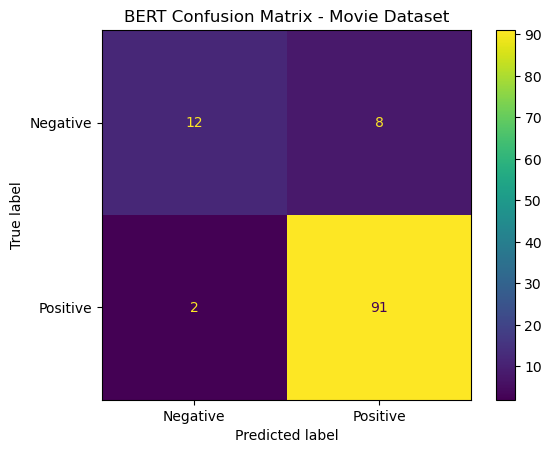

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("BERT Confusion Matrix - Movie Dataset")
plt.show()

In [49]:
results_df = movie_test.reset_index(drop=True).copy()

results_df["true_label"] = y_true
results_df["pred_label"] = y_pred

label_name = {0: "negative", 1: "positive"}

results_df["true_sentiment"] = results_df["true_label"].map(label_name)
results_df["pred_sentiment"] = results_df["pred_label"].map(label_name)

results_df["correct"] = results_df["true_label"] == results_df["pred_label"]

wrong_df = results_df[results_df["correct"] == False]

print("Number of wrong predictions:", len(wrong_df))
print()
print(wrong_df[["review", "true_sentiment", "pred_sentiment"]].head(10))

Number of wrong predictions: 10

                                                review true_sentiment  \
5    barely been on today! haha i saw Alice In Wond...       negative   
12      Watching the tooth fairy, its quite rubbish :)       negative   
14   Uh, honestly, I want to see Clash of the Titan...       negative   
49   Who watched Valentine's Day? I'm gonna watch i...       negative   
50   Death at a Funeral was hilarious. Loser didn't...       positive   
51   Just caught Clash of the Titans. Uneven. Middl...       negative   
77   HYSTERICAL! LMAO! RT @username    Watching the...       negative   
81   Ok, the Tooth Fairy was lame. Kids will love i...       negative   
87   Saw Shutter Island yesterday. That's two hours...       negative   
109  Watching from Paris with love. This shit is cr...       positive   

    pred_sentiment  
5         positive  
12        positive  
14        positive  
49        positive  
50        negative  
51        positive  
77        positi

In [51]:
print("Movie:", movie_df.shape)
print("Irony:", irony_df.shape)
print(irony_train_ds)
print(irony_test_ds)

Movie: (561, 3)
Irony: (65, 3)
Dataset({
    features: ['review', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 52
})
Dataset({
    features: ['review', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 13
})


In [52]:
from transformers import AutoModelForSequenceClassification

irony_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("Fresh BERT model loaded for Irony")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh BERT model loaded for Irony


In [53]:
from transformers import TrainingArguments

irony_training_args = TrainingArguments(
    output_dir="./bert_irony_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_strategy="epoch",
    report_to="none"
)

print("Irony training settings ready")

Irony training settings ready


In [54]:
from transformers import Trainer

irony_trainer = Trainer(
    model=irony_model,
    args=irony_training_args,
    train_dataset=irony_train_ds,
    eval_dataset=irony_test_ds,
    compute_metrics=compute_metrics
)

print("Irony trainer ready")

Irony trainer ready


In [55]:
irony_trainer.train()

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.711466,0.584925,0.692308,0.479290,0.692308,0.566434
2,0.603651,0.583105,0.692308,0.479290,0.692308,0.566434
3,0.583668,0.583122,0.692308,0.479290,0.692308,0.566434


C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=21, training_loss=0.632928416842506, metrics={'train_runtime': 87.0867, 'train_samples_per_second': 1.791, 'train_steps_per_second': 0.241, 'total_flos': 10261331159040.0, 'train_loss': 0.632928416842506, 'epoch': 3.0})

In [56]:
from sklearn.metrics import classification_report, confusion_matrix

irony_predictions = irony_trainer.predict(irony_test_ds)

irony_y_pred = irony_predictions.predictions.argmax(axis=-1)
irony_y_true = irony_predictions.label_ids

print(classification_report(
    irony_y_true,
    irony_y_pred,
    target_names=["negative", "positive"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(irony_y_true, irony_y_pred))

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    negative       0.69      1.00      0.82         9
    positive       0.00      0.00      0.00         4

    accuracy                           0.69        13
   macro avg       0.35      0.50      0.41        13
weighted avg       0.48      0.69      0.57        13


Confusion Matrix:
[[9 0]
 [4 0]]


In [57]:
import pandas as pd

semeval18_df = pd.read_csv(
    r"C:\Users\karth\OneDrive\Desktop\NLP poster\data\SemEval18.csv"
)

print("Shape:", semeval18_df.shape)

print("\nColumns:")
print(semeval18_df.columns.tolist())

print("\nFirst 5 rows:")
print(semeval18_df.head())

print("\nMissing values:")
print(semeval18_df.isnull().sum())

Shape: (1859, 2)

Columns:
['sentiment', 'review']

First 5 rows:
  sentiment                                             review
0  positive  @1barkcom Thank you for the #follow. Looking f...
1  positive                             Smile!!! #happy #smile
2  positive  EEEEEKKKK!!!! Product LAUNCH 😍✋💖 I'm am litera...
3  positive  @xiankiefer @TheLincoln Book 5! It's so sprigh...
4  positive  What if.... the Metro LRT went over the Walter...

Missing values:
sentiment    0
review       0
dtype: int64


In [58]:
print(semeval18_df["sentiment"].value_counts())

print("\nPercentages:")
print(semeval18_df["sentiment"].value_counts(normalize=True) * 100)

sentiment
negative    994
positive    865
Name: count, dtype: int64

Percentages:
sentiment
negative    53.469607
positive    46.530393
Name: proportion, dtype: float64


In [59]:
label_map = {
    "negative": 0,
    "positive": 1
}

semeval18_df["label"] = semeval18_df["sentiment"].map(label_map)

print(semeval18_df.head())
print("\nLabel counts:")
print(semeval18_df["label"].value_counts())

  sentiment                                             review  label
0  positive  @1barkcom Thank you for the #follow. Looking f...      1
1  positive                             Smile!!! #happy #smile      1
2  positive  EEEEEKKKK!!!! Product LAUNCH 😍✋💖 I'm am litera...      1
3  positive  @xiankiefer @TheLincoln Book 5! It's so sprigh...      1
4  positive  What if.... the Metro LRT went over the Walter...      1

Label counts:
label
0    994
1    865
Name: count, dtype: int64


In [60]:
from sklearn.model_selection import train_test_split

semeval18_train, semeval18_test = train_test_split(
    semeval18_df,
    test_size=0.2,
    random_state=42,
    stratify=semeval18_df["label"]
)

print("Train shape:", semeval18_train.shape)
print("Test shape:", semeval18_test.shape)

print("\nTrain label distribution:")
print(semeval18_train["label"].value_counts(normalize=True))

print("\nTest label distribution:")
print(semeval18_test["label"].value_counts(normalize=True))

Train shape: (1487, 3)
Test shape: (372, 3)

Train label distribution:
label
0    0.534633
1    0.465367
Name: proportion, dtype: float64

Test label distribution:
label
0    0.534946
1    0.465054
Name: proportion, dtype: float64


In [61]:
from datasets import Dataset

semeval18_train_ds = Dataset.from_pandas(
    semeval18_train[["review", "label"]],
    preserve_index=False
)

semeval18_test_ds = Dataset.from_pandas(
    semeval18_test[["review", "label"]],
    preserve_index=False
)

print(semeval18_train_ds)
print(semeval18_test_ds)

Dataset({
    features: ['review', 'label'],
    num_rows: 1487
})
Dataset({
    features: ['review', 'label'],
    num_rows: 372
})


In [62]:
def tokenize_function(batch):
    return tokenizer(
        batch["review"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

semeval18_train_ds = semeval18_train_ds.map(
    tokenize_function,
    batched=True
)

semeval18_test_ds = semeval18_test_ds.map(
    tokenize_function,
    batched=True
)

print("SemEval18 tokenization complete")

Map:   0%|          | 0/1487 [00:00<?, ? examples/s]

Map:   0%|          | 0/372 [00:00<?, ? examples/s]

SemEval18 tokenization complete


In [63]:
from transformers import AutoModelForSequenceClassification

semeval18_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("Fresh BERT model loaded for SemEval18")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh BERT model loaded for SemEval18


In [64]:
from transformers import TrainingArguments

semeval18_training_args = TrainingArguments(
    output_dir="./bert_semeval18_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_strategy="epoch",
    report_to="none"
)

print("SemEval18 training settings ready")

SemEval18 training settings ready


In [65]:
from transformers import Trainer

semeval18_trainer = Trainer(
    model=semeval18_model,
    args=semeval18_training_args,
    train_dataset=semeval18_train_ds,
    eval_dataset=semeval18_test_ds,
    compute_metrics=compute_metrics
)

print("SemEval18 trainer ready")

SemEval18 trainer ready


In [66]:
semeval18_trainer.train()

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.390303,0.349205,0.887097,0.889337,0.887097,0.886541
2,0.171094,0.384817,0.905914,0.906245,0.905914,0.905756
3,0.079225,0.434435,0.900538,0.901148,0.900538,0.900309


C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=558, training_loss=0.21354082921072573, metrics={'train_runtime': 2312.1998, 'train_samples_per_second': 1.929, 'train_steps_per_second': 0.241, 'total_flos': 293434604490240.0, 'train_loss': 0.21354082921072573, 'epoch': 3.0})

In [67]:
from sklearn.metrics import classification_report, confusion_matrix

semeval18_predictions = semeval18_trainer.predict(semeval18_test_ds)

semeval18_y_pred = semeval18_predictions.predictions.argmax(axis=-1)
semeval18_y_true = semeval18_predictions.label_ids

print(classification_report(
    semeval18_y_true,
    semeval18_y_pred,
    target_names=["negative", "positive"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(semeval18_y_true, semeval18_y_pred))

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    negative       0.89      0.93      0.91       199
    positive       0.91      0.87      0.89       173

    accuracy                           0.90       372
   macro avg       0.90      0.90      0.90       372
weighted avg       0.90      0.90      0.90       372


Confusion Matrix:
[[185  14]
 [ 23 150]]


In [68]:
from sklearn.model_selection import train_test_split

# First: 70% train, 30% temporary
semeval18_train_final, semeval18_temp = train_test_split(
    semeval18_df,
    test_size=0.30,
    random_state=42,
    stratify=semeval18_df["label"]
)

# Split temporary set equally into validation and test
semeval18_val_final, semeval18_test_final = train_test_split(
    semeval18_temp,
    test_size=0.50,
    random_state=42,
    stratify=semeval18_temp["label"]
)

print("Train:", semeval18_train_final.shape)
print("Validation:", semeval18_val_final.shape)
print("Test:", semeval18_test_final.shape)

Train: (1301, 3)
Validation: (279, 3)
Test: (279, 3)


In [69]:
from datasets import Dataset

semeval18_train_final_ds = Dataset.from_pandas(
    semeval18_train_final[["review", "label"]],
    preserve_index=False
)

semeval18_val_final_ds = Dataset.from_pandas(
    semeval18_val_final[["review", "label"]],
    preserve_index=False
)

semeval18_test_final_ds = Dataset.from_pandas(
    semeval18_test_final[["review", "label"]],
    preserve_index=False
)

print(semeval18_train_final_ds)
print(semeval18_val_final_ds)
print(semeval18_test_final_ds)

Dataset({
    features: ['review', 'label'],
    num_rows: 1301
})
Dataset({
    features: ['review', 'label'],
    num_rows: 279
})
Dataset({
    features: ['review', 'label'],
    num_rows: 279
})


In [70]:
semeval18_train_final_ds = semeval18_train_final_ds.map(
    tokenize_function,
    batched=True
)

semeval18_val_final_ds = semeval18_val_final_ds.map(
    tokenize_function,
    batched=True
)

semeval18_test_final_ds = semeval18_test_final_ds.map(
    tokenize_function,
    batched=True
)

print("Final SemEval18 splits tokenized")

Map:   0%|          | 0/1301 [00:00<?, ? examples/s]

Map:   0%|          | 0/279 [00:00<?, ? examples/s]

Map:   0%|          | 0/279 [00:00<?, ? examples/s]

Final SemEval18 splits tokenized


In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    precision_weighted, recall_weighted, f1_weighted, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }

print("Final evaluation metrics ready")

Final evaluation metrics ready


In [72]:
from transformers import AutoModelForSequenceClassification

bert_final_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("Fresh BERT loaded for final experiment")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh BERT loaded for final experiment


In [73]:
from transformers import TrainingArguments

bert_final_args = TrainingArguments(
    output_dir="./final_bert_semeval18",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,
    weight_decay=0.01,

    seed=42,

    logging_strategy="epoch",
    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    save_total_limit=1
)

print("Final BERT training configuration ready")

Final BERT training configuration ready


In [74]:
from transformers import Trainer

bert_final_trainer = Trainer(
    model=bert_final_model,
    args=bert_final_args,
    train_dataset=semeval18_train_final_ds,
    eval_dataset=semeval18_val_final_ds,
    compute_metrics=compute_metrics
)

print("Final BERT trainer ready")

Final BERT trainer ready


In [75]:
bert_final_trainer.train()

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.413109,0.359111,0.888889,0.888256,0.888616,0.888424,0.888963,0.888889,0.888915
2,0.170246,0.433302,0.896057,0.896805,0.894347,0.895282,0.896315,0.896057,0.895896
3,0.059913,0.498162,0.899642,0.899550,0.898684,0.899070,0.899626,0.899642,0.899587


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=489, training_loss=0.2144227291177387, metrics={'train_runtime': 4653.8027, 'train_samples_per_second': 0.839, 'train_steps_per_second': 0.105, 'total_flos': 256730612267520.0, 'train_loss': 0.2144227291177387, 'epoch': 3.0})

In [76]:
bert_test_output = bert_final_trainer.predict(
    semeval18_test_final_ds
)

bert_test_pred = bert_test_output.predictions.argmax(axis=-1)
bert_test_true = bert_test_output.label_ids

print("FINAL BERT TEST RESULTS")
print(bert_test_output.metrics)

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


FINAL BERT TEST RESULTS
{'test_loss': 0.38102322816848755, 'test_accuracy': 0.9139784946236559, 'test_precision_macro': 0.9153225806451613, 'test_recall_macro': 0.9121063500258131, 'test_f1_macro': 0.9132822213012847, 'test_precision_weighted': 0.9144987859868192, 'test_recall_weighted': 0.9139784946236559, 'test_f1_weighted': 0.9138113890262867, 'test_runtime': 34.5628, 'test_samples_per_second': 8.072, 'test_steps_per_second': 1.013}


In [77]:
from sklearn.metrics import classification_report, confusion_matrix

print(
    classification_report(
        bert_test_true,
        bert_test_pred,
        target_names=["negative", "positive"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(bert_test_true, bert_test_pred))

              precision    recall  f1-score   support

    negative       0.90      0.94      0.92       149
    positive       0.93      0.88      0.91       130

    accuracy                           0.91       279
   macro avg       0.92      0.91      0.91       279
weighted avg       0.91      0.91      0.91       279

Confusion Matrix:
[[140   9]
 [ 15 115]]


In [78]:
from transformers import AutoTokenizer

roberta_tokenizer = AutoTokenizer.from_pretrained(
    "roberta-base"
)

print("RoBERTa tokenizer loaded")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

C:\Users\karth\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\karth\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RoBERTa tokenizer loaded


In [79]:
from datasets import Dataset

# Create fresh datasets from the same final splits
roberta_train_ds = Dataset.from_pandas(
    semeval18_train_final[["review", "label"]],
    preserve_index=False
)

roberta_val_ds = Dataset.from_pandas(
    semeval18_val_final[["review", "label"]],
    preserve_index=False
)

roberta_test_ds = Dataset.from_pandas(
    semeval18_test_final[["review", "label"]],
    preserve_index=False
)

def roberta_tokenize(batch):
    return roberta_tokenizer(
        batch["review"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

roberta_train_ds = roberta_train_ds.map(roberta_tokenize, batched=True)
roberta_val_ds = roberta_val_ds.map(roberta_tokenize, batched=True)
roberta_test_ds = roberta_test_ds.map(roberta_tokenize, batched=True)

print("RoBERTa datasets tokenized")

Map:   0%|          | 0/1301 [00:00<?, ? examples/s]

Map:   0%|          | 0/279 [00:00<?, ? examples/s]

Map:   0%|          | 0/279 [00:00<?, ? examples/s]

RoBERTa datasets tokenized


In [80]:
from transformers import AutoModelForSequenceClassification

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

print("Fresh RoBERTa model loaded")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh RoBERTa model loaded


In [81]:
from transformers import TrainingArguments

roberta_args = TrainingArguments(
    output_dir="./final_roberta_semeval18",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,
    weight_decay=0.01,

    seed=42,

    logging_strategy="epoch",
    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    save_total_limit=1
)

print("RoBERTa training configuration ready")

RoBERTa training configuration ready


In [82]:
from transformers import Trainer

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=roberta_train_ds,
    eval_dataset=roberta_val_ds,
    compute_metrics=compute_metrics
)

print("RoBERTa trainer ready")

RoBERTa trainer ready


In [83]:
roberta_trainer.train()

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.456107,0.471155,0.860215,0.879742,0.852452,0.855951,0.874924,0.860215,0.857639
2,0.257996,0.523271,0.881720,0.884663,0.885338,0.881714,0.888390,0.881720,0.881772
3,0.125181,0.534938,0.906810,0.907330,0.905395,0.906172,0.906964,0.906810,0.906699


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=489, training_loss=0.2797613709494624, metrics={'train_runtime': 2145.5464, 'train_samples_per_second': 1.819, 'train_steps_per_second': 0.228, 'total_flos': 256730612267520.0, 'train_loss': 0.2797613709494624, 'epoch': 3.0})

In [84]:
import pandas as pd

roberta_logs = pd.DataFrame(roberta_trainer.state.log_history)

roberta_epoch_results = roberta_logs[
    roberta_logs["eval_loss"].notna()
][[
    "epoch",
    "eval_loss",
    "eval_accuracy",
    "eval_precision_macro",
    "eval_recall_macro",
    "eval_f1_macro",
    "eval_f1_weighted"
]]

print(roberta_epoch_results.to_string(index=False))

 epoch  eval_loss  eval_accuracy  eval_precision_macro  eval_recall_macro  eval_f1_macro  eval_f1_weighted
   1.0   0.471155       0.860215              0.879742           0.852452       0.855951          0.857639
   2.0   0.523271       0.881720              0.884663           0.885338       0.881714          0.881772
   3.0   0.534938       0.906810              0.907330           0.905395       0.906172          0.906699


In [85]:
roberta_test_output = roberta_trainer.predict(
    roberta_test_ds
)

roberta_test_pred = roberta_test_output.predictions.argmax(axis=-1)
roberta_test_true = roberta_test_output.label_ids

print("FINAL ROBERTA TEST RESULTS")
print(roberta_test_output.metrics)

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


FINAL ROBERTA TEST RESULTS
{'test_loss': 0.3428044021129608, 'test_accuracy': 0.9354838709677419, 'test_precision_macro': 0.9356374172185431, 'test_recall_macro': 0.9346928239545689, 'test_f1_macro': 0.9351162790697674, 'test_precision_weighted': 0.9355105746635334, 'test_recall_weighted': 0.9354838709677419, 'test_f1_weighted': 0.9354488622155539, 'test_runtime': 34.8692, 'test_samples_per_second': 8.001, 'test_steps_per_second': 1.004}


In [86]:
from sklearn.metrics import classification_report, confusion_matrix

print(
    classification_report(
        roberta_test_true,
        roberta_test_pred,
        target_names=["negative", "positive"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(roberta_test_true, roberta_test_pred))

              precision    recall  f1-score   support

    negative       0.93      0.95      0.94       149
    positive       0.94      0.92      0.93       130

    accuracy                           0.94       279
   macro avg       0.94      0.93      0.94       279
weighted avg       0.94      0.94      0.94       279

Confusion Matrix:
[[141   8]
 [ 10 120]]


In [87]:
from transformers import AutoTokenizer

xlnet_tokenizer = AutoTokenizer.from_pretrained(
    "xlnet-base-cased"
)

print("XLNet tokenizer loaded")

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

C:\Users\karth\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\karth\.cache\huggingface\hub\models--xlnet-base-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

XLNet tokenizer loaded


In [88]:
from datasets import Dataset

xlnet_train_ds = Dataset.from_pandas(
    semeval18_train_final[["review", "label"]],
    preserve_index=False
)

xlnet_val_ds = Dataset.from_pandas(
    semeval18_val_final[["review", "label"]],
    preserve_index=False
)

xlnet_test_ds = Dataset.from_pandas(
    semeval18_test_final[["review", "label"]],
    preserve_index=False
)

def xlnet_tokenize(batch):
    return xlnet_tokenizer(
        batch["review"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

xlnet_train_ds = xlnet_train_ds.map(xlnet_tokenize, batched=True)
xlnet_val_ds = xlnet_val_ds.map(xlnet_tokenize, batched=True)
xlnet_test_ds = xlnet_test_ds.map(xlnet_tokenize, batched=True)

print("XLNet datasets tokenized")

Map:   0%|          | 0/1301 [00:00<?, ? examples/s]

Map:   0%|          | 0/279 [00:00<?, ? examples/s]

Map:   0%|          | 0/279 [00:00<?, ? examples/s]

XLNet datasets tokenized


In [89]:
from transformers import AutoModelForSequenceClassification

xlnet_model = AutoModelForSequenceClassification.from_pretrained(
    "xlnet-base-cased",
    num_labels=2
)

print("Fresh XLNet model loaded")

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.weight                  | UNEXPECTED | 
lm_loss.bias                    | UNEXPECTED | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.bias                | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh XLNet model loaded


In [90]:
from transformers import TrainingArguments

xlnet_args = TrainingArguments(
    output_dir="./final_xlnet_semeval18",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,
    weight_decay=0.01,

    seed=42,

    logging_strategy="epoch",
    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    save_total_limit=1
)

print("XLNet training configuration ready")

XLNet training configuration ready


In [91]:
from transformers import Trainer

xlnet_trainer = Trainer(
    model=xlnet_model,
    args=xlnet_args,
    train_dataset=xlnet_train_ds,
    eval_dataset=xlnet_val_ds,
    compute_metrics=compute_metrics
)

print("XLNet trainer ready")

XLNet trainer ready


In [92]:
xlnet_trainer.train()

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.467496,0.465455,0.853047,0.864921,0.846722,0.849639,0.861450,0.853047,0.851181
2,0.311392,0.782512,0.853047,0.855906,0.856531,0.853039,0.859528,0.853047,0.853111
3,0.192073,0.649328,0.874552,0.874508,0.873232,0.873767,0.874541,0.874552,0.874445


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=489, training_loss=0.3236537535497747, metrics={'train_runtime': 2913.3947, 'train_samples_per_second': 1.34, 'train_steps_per_second': 0.168, 'total_flos': 277971932772864.0, 'train_loss': 0.3236537535497747, 'epoch': 3.0})

In [93]:
import pandas as pd

xlnet_logs = pd.DataFrame(xlnet_trainer.state.log_history)

xlnet_epoch_results = xlnet_logs[
    xlnet_logs["eval_loss"].notna()
][[
    "epoch",
    "eval_loss",
    "eval_accuracy",
    "eval_precision_macro",
    "eval_recall_macro",
    "eval_f1_macro",
    "eval_f1_weighted"
]]

print(xlnet_epoch_results.to_string(index=False))

 epoch  eval_loss  eval_accuracy  eval_precision_macro  eval_recall_macro  eval_f1_macro  eval_f1_weighted
   1.0   0.465455       0.853047              0.864921           0.846722       0.849639          0.851181
   2.0   0.782512       0.853047              0.855906           0.856531       0.853039          0.853111
   3.0   0.649328       0.874552              0.874508           0.873232       0.873767          0.874445


In [94]:
xlnet_test_output = xlnet_trainer.predict(
    xlnet_test_ds
)

xlnet_test_pred = xlnet_test_output.predictions.argmax(axis=-1)
xlnet_test_true = xlnet_test_output.label_ids

print("FINAL XLNET TEST RESULTS")
print(xlnet_test_output.metrics)

C:\Users\karth\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


FINAL XLNET TEST RESULTS
{'test_loss': 0.5033256411552429, 'test_accuracy': 0.9068100358422939, 'test_precision_macro': 0.9080645161290322, 'test_recall_macro': 0.9049044914816726, 'test_f1_macro': 0.9060557397430584, 'test_precision_weighted': 0.9072956411145797, 'test_recall_weighted': 0.9068100358422939, 'test_f1_weighted': 0.9066290047784773, 'test_runtime': 155.5867, 'test_samples_per_second': 1.793, 'test_steps_per_second': 0.225}


In [95]:
from sklearn.metrics import classification_report, confusion_matrix

print(
    classification_report(
        xlnet_test_true,
        xlnet_test_pred,
        target_names=["negative", "positive"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(xlnet_test_true, xlnet_test_pred))

              precision    recall  f1-score   support

    negative       0.90      0.93      0.91       149
    positive       0.92      0.88      0.90       130

    accuracy                           0.91       279
   macro avg       0.91      0.90      0.91       279
weighted avg       0.91      0.91      0.91       279

Confusion Matrix:
[[139  10]
 [ 16 114]]


In [96]:
xlnet_report = classification_report(
    xlnet_test_true,
    xlnet_test_pred,
    target_names=["negative", "positive"],
    output_dict=True,
    zero_division=0
)

xlnet_result = {
    "model": "XLNet",
    "accuracy": xlnet_test_output.metrics["test_accuracy"],
    "macro_f1": xlnet_test_output.metrics["test_f1_macro"],
    "weighted_f1": xlnet_test_output.metrics["test_f1_weighted"],
    "negative_f1": xlnet_report["negative"]["f1-score"],
    "positive_f1": xlnet_report["positive"]["f1-score"],
    "best_epoch": 3,
    "best_val_macro_f1": 0.873767
}

results.append(xlnet_result)

print(results)

NameError: name 'results' is not defined

In [97]:
print("BERT trainer:", "bert_final_trainer" in globals())
print("RoBERTa trainer:", "roberta_trainer" in globals())
print("XLNet trainer:", "xlnet_trainer" in globals())

print("BERT model:", "bert_final_model" in globals())
print("RoBERTa model:", "roberta_model" in globals())
print("XLNet model:", "xlnet_model" in globals())

print("Results list:", "results" in globals())

BERT trainer: True
RoBERTa trainer: True
XLNet trainer: True
BERT model: True
RoBERTa model: True
XLNet model: True
Results list: False


In [98]:
from sklearn.metrics import classification_report

def best_validation_result(trainer):
    eval_logs = [
        x for x in trainer.state.log_history
        if "eval_f1_macro" in x
    ]
    best = max(eval_logs, key=lambda x: x["eval_f1_macro"])
    return best["epoch"], best["eval_f1_macro"]


# BERT
bert_report = classification_report(
    bert_test_true,
    bert_test_pred,
    target_names=["negative", "positive"],
    output_dict=True,
    zero_division=0
)

bert_best_epoch, bert_best_val = best_validation_result(
    bert_final_trainer
)

# RoBERTa
roberta_report = classification_report(
    roberta_test_true,
    roberta_test_pred,
    target_names=["negative", "positive"],
    output_dict=True,
    zero_division=0
)

roberta_best_epoch, roberta_best_val = best_validation_result(
    roberta_trainer
)

# XLNet
xlnet_report = classification_report(
    xlnet_test_true,
    xlnet_test_pred,
    target_names=["negative", "positive"],
    output_dict=True,
    zero_division=0
)

xlnet_best_epoch, xlnet_best_val = best_validation_result(
    xlnet_trainer
)


results = [
    {
        "model": "BERT",
        "accuracy": bert_test_output.metrics["test_accuracy"],
        "macro_f1": bert_test_output.metrics["test_f1_macro"],
        "weighted_f1": bert_test_output.metrics["test_f1_weighted"],
        "negative_f1": bert_report["negative"]["f1-score"],
        "positive_f1": bert_report["positive"]["f1-score"],
        "best_epoch": bert_best_epoch,
        "best_val_macro_f1": bert_best_val
    },
    {
        "model": "RoBERTa",
        "accuracy": roberta_test_output.metrics["test_accuracy"],
        "macro_f1": roberta_test_output.metrics["test_f1_macro"],
        "weighted_f1": roberta_test_output.metrics["test_f1_weighted"],
        "negative_f1": roberta_report["negative"]["f1-score"],
        "positive_f1": roberta_report["positive"]["f1-score"],
        "best_epoch": roberta_best_epoch,
        "best_val_macro_f1": roberta_best_val
    },
    {
        "model": "XLNet",
        "accuracy": xlnet_test_output.metrics["test_accuracy"],
        "macro_f1": xlnet_test_output.metrics["test_f1_macro"],
        "weighted_f1": xlnet_test_output.metrics["test_f1_weighted"],
        "negative_f1": xlnet_report["negative"]["f1-score"],
        "positive_f1": xlnet_report["positive"]["f1-score"],
        "best_epoch": xlnet_best_epoch,
        "best_val_macro_f1": xlnet_best_val
    }
]

results

[{'model': 'BERT',
  'accuracy': 0.9139784946236559,
  'macro_f1': 0.9132822213012847,
  'weighted_f1': 0.9138113890262867,
  'negative_f1': 0.9210526315789473,
  'positive_f1': 0.905511811023622,
  'best_epoch': 3.0,
  'best_val_macro_f1': 0.8990697674418604},
 {'model': 'RoBERTa',
  'accuracy': 0.9354838709677419,
  'macro_f1': 0.9351162790697674,
  'weighted_f1': 0.9354488622155539,
  'negative_f1': 0.94,
  'positive_f1': 0.9302325581395349,
  'best_epoch': 3.0,
  'best_val_macro_f1': 0.906172392384106},
 {'model': 'XLNet',
  'accuracy': 0.9068100358422939,
  'macro_f1': 0.9060557397430584,
  'weighted_f1': 0.9066290047784773,
  'negative_f1': 0.9144736842105263,
  'positive_f1': 0.8976377952755905,
  'best_epoch': 3.0,
  'best_val_macro_f1': 0.8737670799022713}]

In [99]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df["accuracy"] = results_df["accuracy"] * 100
results_df["macro_f1"] = results_df["macro_f1"] * 100
results_df["weighted_f1"] = results_df["weighted_f1"] * 100
results_df["negative_f1"] = results_df["negative_f1"] * 100
results_df["positive_f1"] = results_df["positive_f1"] * 100
results_df["best_val_macro_f1"] = results_df["best_val_macro_f1"] * 100

results_df = results_df.round(2)

results_df

,model,accuracy,macro_f1,weighted_f1,negative_f1,positive_f1,best_epoch,best_val_macro_f1
0,BERT,91.40,91.33,91.38,92.11,90.55,3.0,89.91
1,RoBERTa,93.55,93.51,93.54,94.00,93.02,3.0,90.62
2,XLNet,90.68,90.61,90.66,91.45,89.76,3.0,87.38


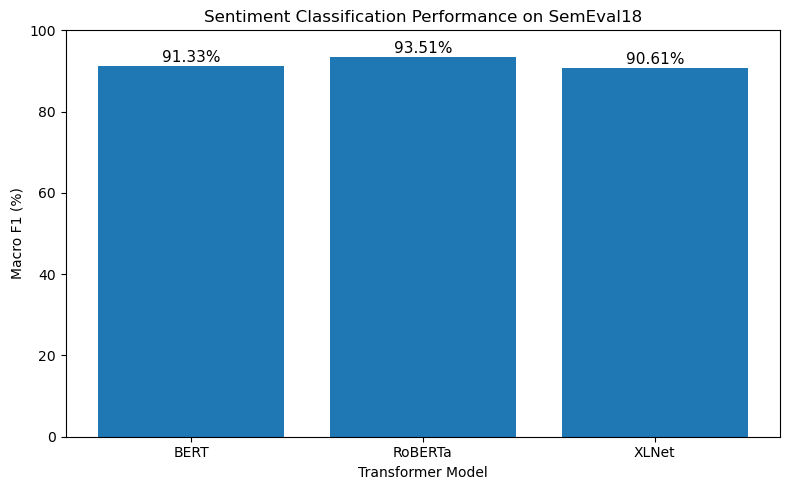

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results_df["model"],
    results_df["macro_f1"]
)

plt.ylabel("Macro F1 (%)")
plt.xlabel("Transformer Model")
plt.title("Sentiment Classification Performance on SemEval18")
plt.ylim(0, 100)

for bar, value in zip(bars, results_df["macro_f1"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "model_macro_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

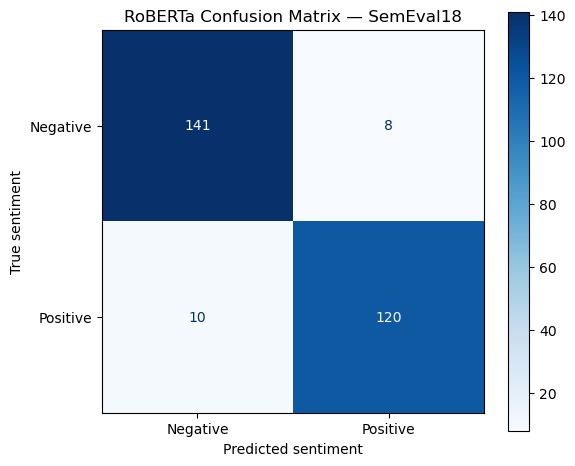

In [101]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(
    roberta_test_true,
    roberta_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("RoBERTa Confusion Matrix — SemEval18")
plt.xlabel("Predicted sentiment")
plt.ylabel("True sentiment")

plt.tight_layout()

plt.savefig(
    "roberta_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [102]:
error_analysis = semeval18_test_final.copy()

error_analysis["true_label"] = roberta_test_true
error_analysis["predicted_label"] = roberta_test_pred

wrong_predictions = error_analysis[
    error_analysis["true_label"] != error_analysis["predicted_label"]
].copy()

wrong_predictions["true_sentiment"] = wrong_predictions["true_label"].map({
    0: "negative",
    1: "positive"
})

wrong_predictions["predicted_sentiment"] = wrong_predictions["predicted_label"].map({
    0: "negative",
    1: "positive"
})

print("Number of RoBERTa errors:", len(wrong_predictions))

wrong_predictions[
    ["review", "true_sentiment", "predicted_sentiment"]
].head(10)

Number of RoBERTa errors: 18


,review,true_sentiment,predicted_sentiment
1772,'Too often we give children answers to remembe...,negative,positive
395,@CarolynTopol Ciara asks was it a sci-fi movie...,positive,negative
1208,Welp.. I hope y'all don't have animosity towar...,negative,positive
381,i just read an article titled - what 12 indian...,positive,negative
1584,I think 'Sleep' is my favorite from How did we...,negative,positive
788,The most important characteristic of leadershi...,positive,negative
923,@SimplyMayaMarie @STILLStanding_B 😂😂😂 y'all kn...,positive,negative
326,3:45am and off to the hospital! Elouise's wate...,positive,negative
417,I can't afford to be unhappy. I've made it thi...,positive,negative
665,"@johntassparker Well, at the time, I think the...",positive,negative


In [103]:
pd.set_option("display.max_colwidth", 200)

wrong_predictions[
    ["review", "true_sentiment", "predicted_sentiment"]
].head(18)

,review,true_sentiment,predicted_sentiment
1772,'Too often we give children answers to remember rather than problems to solve' Roger Lewin Terrific :) Tuesday,negative,positive
395,"@CarolynTopol Ciara asks was it a sci-fi movie, Julie &amp; Jen just stare, Claire on her phone, Joey bolts when the cab honks. LMAO",positive,negative
1208,Welp.. I hope y'all don't have animosity towards me &amp; find this new one. 🙇🏽‍♀️,negative,positive
381,i just read an article titled - what 12 indian men think about women's fashion choices and im so done with the internet for today. #ironic,positive,negative
1584,"I think 'Sleep' is my favorite from How did we get so dark?, maybe because I'm insomniac",negative,positive
788,The most important characteristic of leadership is the lack of #fear. #activism #equity #revolution,positive,negative
923,@SimplyMayaMarie @STILLStanding_B 😂😂😂 y'all know I'm crazy its just shocking that's all,positive,negative
326,3:45am and off to the hospital! Elouise's waters have gone! #Labour #LittleSister #superexcited,positive,negative
417,I can't afford to be unhappy. I've made it this far and there isn't anything or anyone that's going to take my happiness away.,positive,negative
665,"@johntassparker Well, at the time, I think there was that concern. Now it is all bright and shiny with a price tag to match.",positive,negative


In [104]:
pd.set_option("display.max_colwidth", 200)

wrong_predictions[
    ["review", "true_sentiment", "predicted_sentiment"]
].head(18)

,review,true_sentiment,predicted_sentiment
1772,'Too often we give children answers to remember rather than problems to solve' Roger Lewin Terrific :) Tuesday,negative,positive
395,"@CarolynTopol Ciara asks was it a sci-fi movie, Julie &amp; Jen just stare, Claire on her phone, Joey bolts when the cab honks. LMAO",positive,negative
1208,Welp.. I hope y'all don't have animosity towards me &amp; find this new one. 🙇🏽‍♀️,negative,positive
381,i just read an article titled - what 12 indian men think about women's fashion choices and im so done with the internet for today. #ironic,positive,negative
1584,"I think 'Sleep' is my favorite from How did we get so dark?, maybe because I'm insomniac",negative,positive
788,The most important characteristic of leadership is the lack of #fear. #activism #equity #revolution,positive,negative
923,@SimplyMayaMarie @STILLStanding_B 😂😂😂 y'all know I'm crazy its just shocking that's all,positive,negative
326,3:45am and off to the hospital! Elouise's waters have gone! #Labour #LittleSister #superexcited,positive,negative
417,I can't afford to be unhappy. I've made it this far and there isn't anything or anyone that's going to take my happiness away.,positive,negative
665,"@johntassparker Well, at the time, I think there was that concern. Now it is all bright and shiny with a price tag to match.",positive,negative


In [105]:
pd.set_option("display.max_colwidth", 200)

wrong_predictions[
    ["review", "true_sentiment", "predicted_sentiment"]
].head(18)

,review,true_sentiment,predicted_sentiment
1772,'Too often we give children answers to remember rather than problems to solve' Roger Lewin Terrific :) Tuesday,negative,positive
395,"@CarolynTopol Ciara asks was it a sci-fi movie, Julie &amp; Jen just stare, Claire on her phone, Joey bolts when the cab honks. LMAO",positive,negative
1208,Welp.. I hope y'all don't have animosity towards me &amp; find this new one. 🙇🏽‍♀️,negative,positive
381,i just read an article titled - what 12 indian men think about women's fashion choices and im so done with the internet for today. #ironic,positive,negative
1584,"I think 'Sleep' is my favorite from How did we get so dark?, maybe because I'm insomniac",negative,positive
788,The most important characteristic of leadership is the lack of #fear. #activism #equity #revolution,positive,negative
923,@SimplyMayaMarie @STILLStanding_B 😂😂😂 y'all know I'm crazy its just shocking that's all,positive,negative
326,3:45am and off to the hospital! Elouise's waters have gone! #Labour #LittleSister #superexcited,positive,negative
417,I can't afford to be unhappy. I've made it this far and there isn't anything or anyone that's going to take my happiness away.,positive,negative
665,"@johntassparker Well, at the time, I think there was that concern. Now it is all bright and shiny with a price tag to match.",positive,negative


In [106]:
print(
    wrong_predictions[
        ["review", "true_sentiment", "predicted_sentiment"]
    ].head(18).to_string(index=False)
)

                                                                                                                                      review true_sentiment predicted_sentiment
                              'Too often we give children answers to remember rather than problems to solve' Roger Lewin Terrific :) Tuesday       negative            positive
        @CarolynTopol Ciara asks was it a sci-fi movie, Julie &amp; Jen just stare, Claire on her phone, Joey bolts when the cab honks. LMAO       positive            negative
                                                          Welp.. I hope y'all don't have animosity towards me &amp; find this new one. 🙇🏽‍♀️       negative            positive
  i just read an article titled - what 12 indian men think about women's fashion choices and im so done with the internet for today. #ironic       positive            negative
                                                    I think 'Sleep' is my favorite from How did we get so dark?, maybe b